# Kombinasi 2: Seleksi Aset Cerdas & Optimasi VQE

Notebook ini memperluas konsep sebelumnya dengan menambahkan tahap **Seleksi Aset Klasik** sebelum dilakukan analisis kuantum.

## Tahapan Proses:
1. **Seleksi Aset**: 
   - Mengambil data 4 aset: Emas (`GC=F`), Perak (`SI=F`), BCA (`BBCA.JK`), dan Bitcoin (`BTC-USD`).
   - Menghitung **Sharpe Ratio** (Return/Risk) tahunan.
   - Memilih 2 aset terbaik (High Return, Low Risk).
2. **Quantum Game Theory**: Analisis interaksi strategis antara 2 aset terpilih.
3. **VQE Optimization**: Mencari keadaan pasar paling stabil (Nash Equilibrium) menggunakan komputasi kuantum.

In [1]:
# 1. Setup & Imports
import pennylane as qml
from pennylane import numpy as np
import yfinance as yf
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import scipy.linalg as la

print(f"PennyLane version: {qml.__version__}")

PennyLane version: 0.44.0


In [2]:
# 2. Smart Asset Selection (Classical)

def select_top_assets(tickers, period="2y"):
    print(f"Fetching data for: {tickers}...")
    try:
        data = yf.download(tickers, period=period)['Close']
        # Handle MultiIndex if present
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.get_level_values(0)
        
        returns = data.pct_change().dropna()
        
        # Calculate Annualized Metrics (252 trading days)
        mean_returns = returns.mean() * 252
        volatility = returns.std() * np.sqrt(252)
        
        # Sharpe Ratio (Assuming Risk-Free Rate ~ 0 for comparison)
        sharpe_ratios = mean_returns / volatility
        
        # Create Summary DataFrame
        metrics = pd.DataFrame({
            'Annual Return': mean_returns,
            'Volatility (Risk)': volatility,
            'Sharpe Ratio': sharpe_ratios
        })
        
        print("\n--- Asset Performance Metrics ---")
        print(metrics.sort_values(by='Sharpe Ratio', ascending=False))
        
        # Select Top 2
        top_2 = sharpe_ratios.sort_values(ascending=False).head(2).index.tolist()
        print(f"\nSelected Assets (Top 2 Sharpe): {top_2}")
        
        return top_2, returns[top_2]
        
    except Exception as e:
        print(f"Error in selection: {e}. Using fallback.")
        return ['GC=F', 'SI=F'], pd.DataFrame() # Fallback

tickers = ['GC=F', 'SI=F', 'BBCA.JK', 'BTC-USD']
selected_tickers, selected_returns = select_top_assets(tickers)

Fetching data for: ['GC=F', 'SI=F', 'BBCA.JK', 'BTC-USD']...


[*********************100%***********************]  4 of 4 completed


--- Asset Performance Metrics ---
         Annual Return  Volatility (Risk)  Sharpe Ratio
Ticker                                                 
GC=F          0.454085           0.203338      2.233150
SI=F          0.550338           0.456161      1.206456
BTC-USD       0.093783           0.453334      0.206873
BBCA.JK      -0.003394           0.252986     -0.013417

Selected Assets (Top 2 Sharpe): ['GC=F', 'SI=F']


In [3]:
# 3. Quantum Game Theory Analysis (On Selected Assets)

def analyze_quantum_game(returns, asset_a, asset_b):
    print(f"\nAnalyzing interaction: {asset_a} vs {asset_b}")
    # State 0 (Up), State 1 (Down)
    state_A = (returns[asset_a] < 0).astype(int)
    state_B = (returns[asset_b] < 0).astype(int)

    n_ij = np.zeros((2, 2))
    sum_A = np.zeros((2, 2))
    sum_B = np.zeros((2, 2))

    for i in range(len(returns)):
        a, b = state_A.iloc[i], state_B.iloc[i]
        n_ij[a, b] += 1
        sum_A[a, b] += returns[asset_a].iloc[i]
        sum_B[a, b] += returns[asset_b].iloc[i]

    n_total = n_ij.sum()
    
    # Payoff Matrices (Smoothed)
    payoff_A = sum_A / (n_ij + 1)
    payoff_B = sum_B / (n_ij + 1)

    prob_matrix = n_ij / n_total
    return payoff_A, payoff_B, prob_matrix

def calculate_qmi(probs):
    rho_AB = probs / np.sum(probs)
    rho_A = np.diag([probs[0,0] + probs[0,1], probs[1,0] + probs[1,1]])
    rho_B = np.diag([probs[0,0] + probs[1,0], probs[0,1] + probs[1,1]])

    def vn_entropy(rho):
        ev = la.eigvalsh(rho)
        ev = ev[ev > 1e-12]
        return -np.sum(ev * np.log2(ev))

    return vn_entropy(rho_A) + vn_entropy(rho_B) - vn_entropy(rho_AB)

pA, pB, probs = analyze_quantum_game(selected_returns, selected_tickers[0], selected_tickers[1])
qmi = calculate_qmi(probs)
print(f"Quantum Mutual Information (Entanglement): {qmi:.4f}")


Analyzing interaction: GC=F vs SI=F
Quantum Mutual Information (Entanglement): 0.9675


In [4]:
# 4. Hamiltonian Construction

# H = -h_A * Z0 - h_B * Z1 - J_AB * (Z0 @ Z1)
h_A = (pA[0,0] + pA[0,1]) - (pA[1,0] + pA[1,1])
h_B = (pB[0,0] + pB[1,0]) - (pB[0,1] + pB[1,1])
J_AB = qmi * 0.5

print(f"Hamiltonian Params: h_{selected_tickers[0]}={h_A:.4f}, h_{selected_tickers[1]}={h_B:.4f}, J={J_AB:.4f}")

obs = [qml.PauliZ(0), qml.PauliZ(1), qml.PauliZ(0) @ qml.PauliZ(1)]
coeffs = [-h_A, -h_B, -J_AB]
H = qml.Hamiltonian(coeffs, obs)
print("Hamiltonian:\n", H)

Hamiltonian Params: h_GC=F=0.0285, h_SI=F=0.0579, J=0.4838
Hamiltonian:
 -0.028503926299450803 * Z(0) + -0.05792810794566895 * Z(1) + -0.4837737785248322 * (Z(0) @ Z(1))


Running VQE...
Iter 0: Cost = 0.388516
Iter 20: Cost = -0.485192
Iter 40: Cost = -0.562364
Iter 60: Cost = -0.568757
Iter 80: Cost = -0.569988
Final VQE Energy: -0.570183


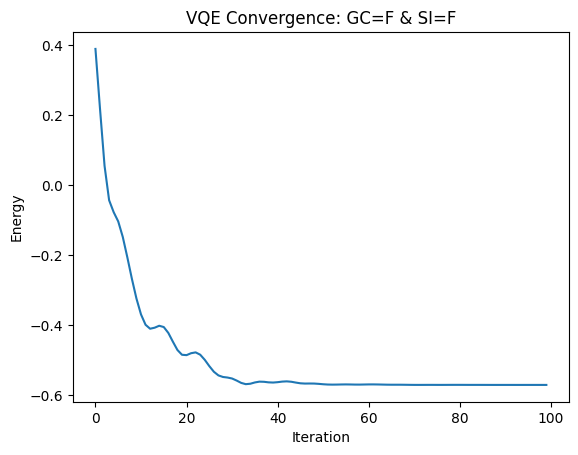

In [5]:
# 5. VQE Optimization (Hardware-Efficient)

n_qubits = 2
depth = 2
dev = qml.device("default.qubit", wires=n_qubits)

def hardware_efficient_ansatz(weights, wires, depth):
    for i in wires:
        qml.RZ(weights[0, i, 0], wires=i)
        qml.RX(weights[0, i, 1], wires=i)
        qml.RZ(weights[0, i, 2], wires=i)
    for d in range(depth):
        qml.CNOT(wires=[wires[0], wires[1]])
        for i in wires:
            qml.RZ(weights[d+1, i, 0], wires=i)
            qml.RX(weights[d+1, i, 1], wires=i)
            qml.RZ(weights[d+1, i, 2], wires=i)

@qml.qnode(dev)
def cost_fn(weights):
    hardware_efficient_ansatz(weights, wires=[0, 1], depth=depth)
    return qml.expval(H)

opt = qml.AdamOptimizer(stepsize=0.1)
param_shape = (depth + 1, n_qubits, 3)
np.random.seed(42)
weights = np.random.random(param_shape, requires_grad=True) * 2 * np.pi

costs = []
print("Running VQE...")
for i in range(100):
    weights, cost = opt.step_and_cost(cost_fn, weights)
    costs.append(cost)
    if i % 20 == 0: print(f"Iter {i}: Cost = {cost:.6f}")

print(f"Final VQE Energy: {costs[-1]:.6f}")

plt.plot(costs)
plt.title(f'VQE Convergence: {selected_tickers[0]} & {selected_tickers[1]}')
plt.ylabel('Energy')
plt.xlabel('Iteration')
plt.show()

In [6]:
# 6. Result & Verification

@qml.qnode(dev)
def get_probs(weights):
    hardware_efficient_ansatz(weights, wires=[0, 1], depth=depth)
    return qml.probs(wires=[0, 1])

probs_vqe = get_probs(weights)
states = ["|00> (Both Up)", "|01> (A Up, B Down)", "|10> (A Down, B Up)", "|11> (Both Down)"]

print(f"\n--- Selected Assets: {selected_tickers} ---")
print("Quantum State Probabilities:")
for s, p in zip(states, probs_vqe):
    print(f"{s}: {p:.4f}")

best_state = states[np.argmax(probs_vqe)]
print(f"\nRecommended Strategy (Nash Eq): {best_state}")

# Exact Check
H_mat = qml.matrix(H)
if hasattr(H_mat, "todense"): H_mat = H_mat.todense()
exact_en = la.eigh(H_mat)[0][0]

print(f"\nVerification:")
print(f"VQE: {costs[-1]:.6f} | Exact: {exact_en:.6f}")
assert abs(costs[-1] - exact_en) < 0.1, "VQE did not converge well!"


--- Selected Assets: ['GC=F', 'SI=F'] ---
Quantum State Probabilities:
|00> (Both Up): 0.9999
|01> (A Up, B Down): 0.0000
|10> (A Down, B Up): 0.0000
|11> (Both Down): 0.0001

Recommended Strategy (Nash Eq): |00> (Both Up)

Verification:
VQE: -0.570183 | Exact: -0.570206


---
gemini try

---

In [1]:
def analyze_bayesian_quantum_game(returns, asset_a, asset_b, prior_belief=0.5):
    # State 0 (Up/Untung), State 1 (Down/Rugi)
    state_A = (returns[asset_a] < 0).astype(int)
    state_B = (returns[asset_b] < 0).astype(int)

    # 1. Inisialisasi Matriks Observasi (Data)
    n_ij = np.zeros((2, 2))
    sum_A = np.zeros((2, 2))
    sum_B = np.zeros((2, 2))

    for i in range(len(returns)):
        a, b = state_A.iloc[i], state_B.iloc[i]
        n_ij[a, b] += 1
        sum_A[a, b] += returns[asset_a].iloc[i]
        sum_B[a, b] += returns[asset_b].iloc[i]

    # 2. BAYESIAN UPDATE (Ini bagian pentingnya!)
    # Kita mulai dengan Prior (Laplace Smoothing/Dirichlet Prior)
    # Anggap kita punya keyakinan awal yang netral (alpha=1)
    alpha = 1.0

    # Posterior counts = Data + Prior
    n_posterior = n_ij + alpha
    n_total_posterior = n_posterior.sum()

    # 3. Probabilitas Posterior (Bayesian Probabilities)
    prob_matrix = n_posterior / n_total_posterior

    # 4. Expected Payoff Matrix (weighted by posterior probability)
    # Kita menormalkan payoff berdasarkan belief baru
    # Hindari pembagian nol dengan menggunakan n_posterior
    payoff_A = sum_A / n_posterior
    payoff_B = sum_B / n_posterior

    return payoff_A, payoff_B, prob_matrix

In [2]:
def game_theory_optimizer_step(cost_fn, current_weights, step_size=0.1):
    new_weights = current_weights.copy()

    # Setiap parameter dianggap sebagai pemain
    for i in range(len(new_weights)):
        # 1. Pemain 'i' mencoba strategi "Naik" (+step)
        weights_plus = new_weights.copy()
        weights_plus[i] += step_size
        cost_plus = cost_fn(weights_plus)

        # 2. Pemain 'i' mencoba strategi "Turun" (-step)
        weights_minus = new_weights.copy()
        weights_minus[i] -= step_size
        cost_minus = cost_fn(weights_minus)

        # 3. Bandingkan dengan biaya saat ini (Nash Decision)
        current_cost = cost_fn(new_weights)

        # Pemain memilih strategi yang paling menguntungkan tim (Energi terendah)
        if cost_plus < current_cost and cost_plus < cost_minus:
            new_weights[i] += step_size # Keputusan: Geser Naik
        elif cost_minus < current_cost and cost_minus < cost_plus:
            new_weights[i] -= step_size # Keputusan: Geser Turun
        # Else: Diam (Nash Equilibrium lokal tercapai untuk pemain ini)

    return new_weights